In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [100]:
df = pd.read_csv('/content/employee_attrition_data.csv')

In [101]:
df.head()

,Employee_ID,Age,Gender,Department,Job_Title,Years_at_Company,Satisfaction_Level,Average_Monthly_Hours,Promotion_Last_5Years,Salary,Attrition
0,0,27,Male,Marketing,Manager,9,0.586251,151,0,60132,0
1,1,53,Female,Sales,Engineer,10,0.261161,221,1,79947,0
2,2,59,Female,Marketing,Analyst,8,0.304382,184,0,46958,1
3,3,42,Female,Engineering,Manager,1,0.480779,242,0,40662,0
4,4,44,Female,Sales,Engineer,10,0.636244,229,1,74307,0


In [90]:
df.isna().sum()

,0
Employee_ID,0
Age,0
Gender,0
Department,0
Job_Title,0
Years_at_Company,0
Satisfaction_Level,0
Average_Monthly_Hours,0
Promotion_Last_5Years,0
Salary,0


In [91]:
df.dropna(inplace=True)

In [92]:
df.isna().sum()

,0
Employee_ID,0
Age,0
Gender,0
Department,0
Job_Title,0
Years_at_Company,0
Satisfaction_Level,0
Average_Monthly_Hours,0
Promotion_Last_5Years,0
Salary,0


In [93]:
from re import T
Total_Attrition = df['Attrition'].value_counts()
Total_Attrition

,count
Attrition,
0,505
1,495


<Axes: xlabel='Attrition'>

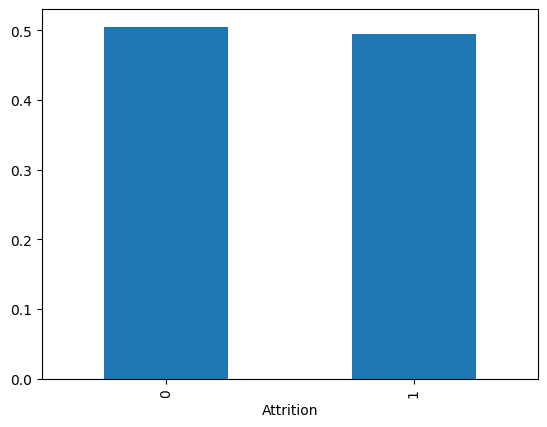

In [11]:
Attrition_rate = df['Attrition'].value_counts(normalize=True)
Attrition_rate.plot(kind='bar')

In [10]:
Total_Employees = df['Employee_ID'].value_counts().sum()
Total_Employees

np.int64(1000)

In [12]:
crosstab = pd.crosstab(df['Attrition'], df['Department'])
crosstab

Department,Engineering,Finance,HR,Marketing,Sales
Attrition,,,,,
0,95,99,95,110,106
1,109,107,96,80,103


<Axes: xlabel='Attrition'>

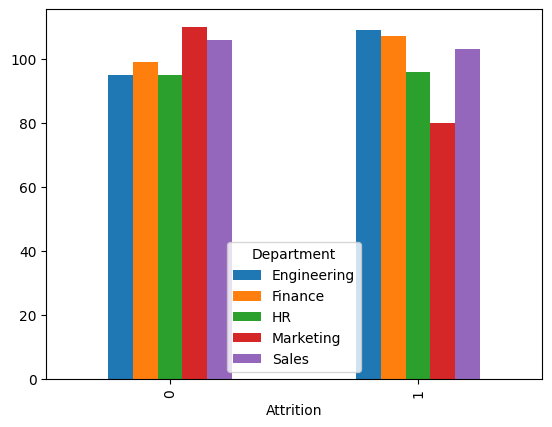

In [13]:
crosstab.plot(kind='bar')

<Axes: xlabel='Attrition'>

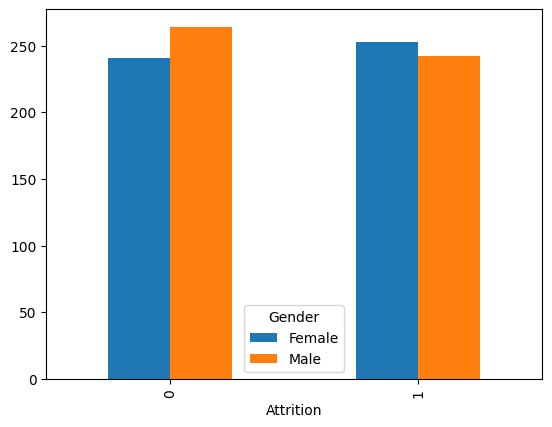

In [14]:
pd.crosstab(df['Attrition'], df['Gender']).plot(kind='bar')

In [30]:
crosstab = pd.crosstab(df['Attrition'], df['Salary']).T
crosstab

Attrition,0,1
Salary,,
30099,0,1
30181,0,1
30194,0,1
30262,0,1
30269,0,1
...,...,...
99672,1,0
99801,0,1
99851,0,1


In [25]:
num_faeture_list1 = [f for f in  df.columns if df.dtypes[f] == 'int64']

num_faeture_list2 = [f for f in  df.columns if df.dtypes[f] == 'float64']

num_faeture_list = num_faeture_list1 + num_faeture_list2

In [26]:
print(num_faeture_list)


['Employee_ID', 'Age', 'Years_at_Company', 'Average_Monthly_Hours', 'Promotion_Last_5Years', 'Salary', 'Attrition', 'Satisfaction_Level']


In [28]:
crosstab = pd.crosstab(df['Attrition'], df['Department']).T
crosstab

Attrition,0,1
Department,,
Engineering,95,109
Finance,99,107
HR,95,96
Marketing,110,80
Sales,106,103


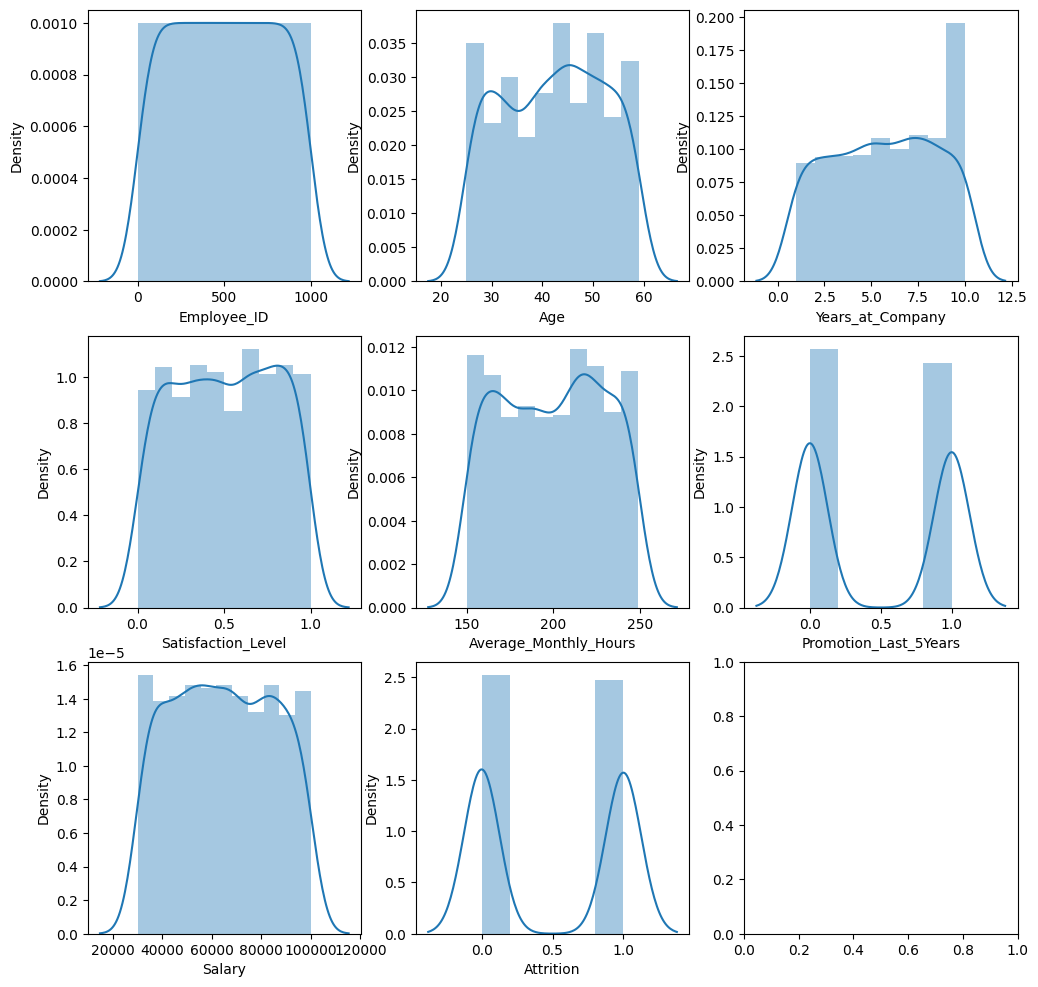

In [32]:
Num_col = df.select_dtypes(include=np.number)
fig,axes = plt.subplots(round(len(Num_col.columns) / 3),3,figsize=(12,12))
for i,ax in enumerate(fig.axes):
  if i < len(Num_col.columns):
    sns.distplot(a=df[Num_col.columns[i]],ax=ax)


<Axes: xlabel='Gender'>

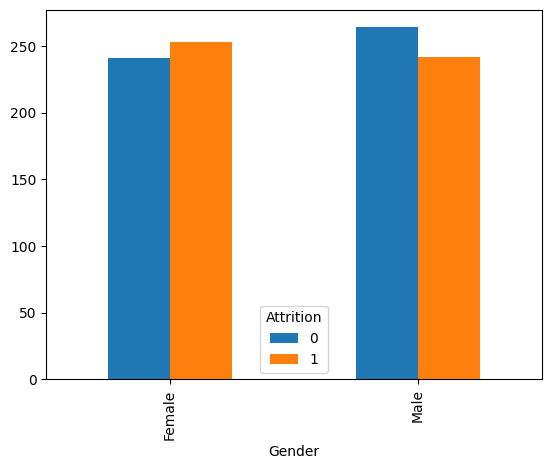

In [34]:
gender = pd.crosstab(df['Attrition'], df['Gender']).T
gender.plot(kind='bar')

<Axes: xlabel='Age'>

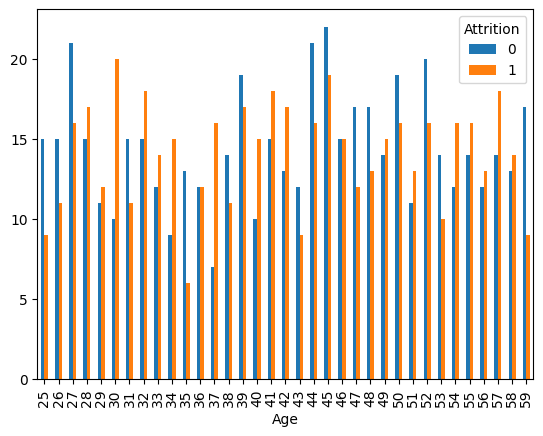

In [35]:
age = pd.crosstab(df['Attrition'], df['Age']).T
age.plot(kind='bar')

([<matplotlib.patches.Wedge at 0x7d3815c62fd0>,
 [Text(0.8646583879229434, 0.679974905562328, 'Accountant'),
  Text(-0.3795005262990821, 1.0324627598798515, 'Analyst'),
  Text(-1.0999113859042102, -0.013962204635364716, 'Engineer'),
  Text(-0.3597745428511371, -1.0395009756206366, 'HR Specialist'),
  Text(0.868956620726573, -0.674473417782684, 'Manager')],
 [Text(0.47163184795796903, 0.37089540303399704, '21.2%'),
  Text(-0.20700028707222656, 0.5631615053890098, '18.8%'),
  Text(-0.59995166503866, -0.007615747982926208, '20.4%'),
  Text(-0.19624065973698385, -0.5670005321567109, '18.6%'),
  Text(0.47397633857813065, -0.3678945915178276, '21.0%')])

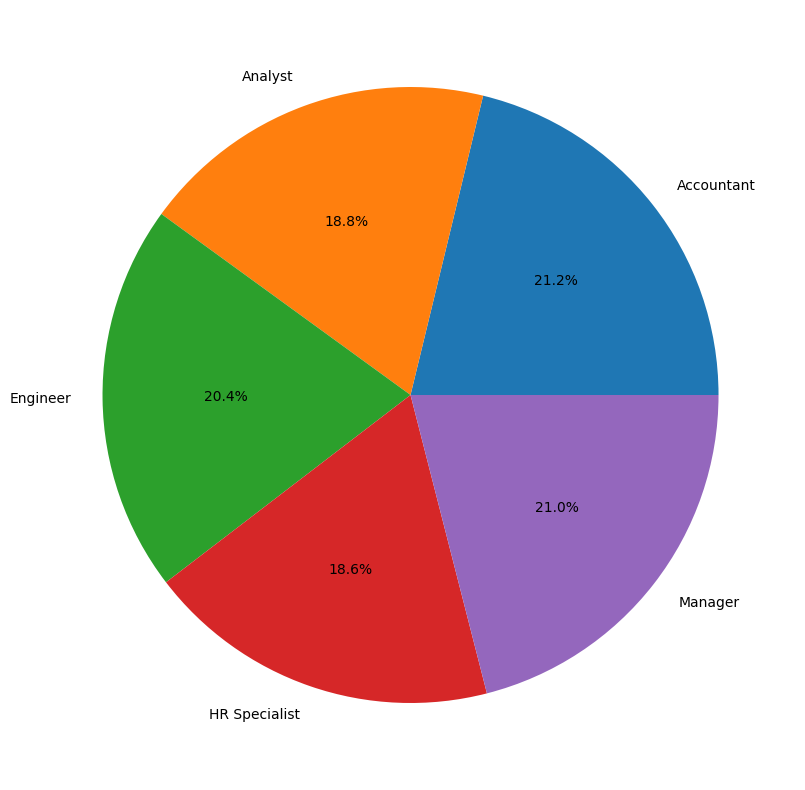

In [44]:
Job_Title = pd.crosstab(df['Attrition'], df['Job_Title']).T
Job_Title
plt.figure(figsize=(10,10))
plt.pie(Job_Title,labels=Job_Title.index,autopct='%1.1f%%')

In [50]:
Year_company = pd.crosstab(df['Attrition'], df['Years_at_Company']).T
Year_company

Attrition,0,1
Years_at_Company,,
1,49,41
2,39,55
3,52,43
4,50,46
5,62,47
6,46,54
7,50,61
8,59,50
9,45,51


<Axes: ylabel='Frequency'>

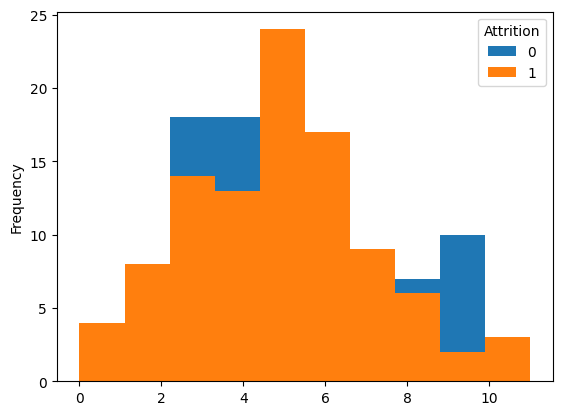

In [54]:
Average_Monthly_Hours = pd.crosstab(df['Attrition'], df['Average_Monthly_Hours']).T
Average_Monthly_Hours.plot(kind='hist')

In [56]:
for feature in df.columns:
  print(feature)
  print(df[feature].nunique())

Employee_ID
1000
Age
35
Gender
2
Department
5
Job_Title
5
Years_at_Company
10
Satisfaction_Level
1000
Average_Monthly_Hours
100
Promotion_Last_5Years
2
Salary
995
Attrition
2


In [106]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Attrition'] = le.fit_transform(df['Attrition'])
df['Department'] = le.fit_transform(df['Department'])
df['Gender'] = le.fit_transform(df['Gender'])
df['Job_Title'] = le.fit_transform(df['Job_Title'])


In [107]:
df.head()

,Employee_ID,Age,Gender,Department,Job_Title,Years_at_Company,Satisfaction_Level,Average_Monthly_Hours,Promotion_Last_5Years,Salary,Attrition
0,0,27,1,3,4,9,0.586251,151,0,60132,0
1,1,53,0,4,2,10,0.261161,221,1,79947,0
2,2,59,0,3,1,8,0.304382,184,0,46958,1
3,3,42,0,0,4,1,0.480779,242,0,40662,0
4,4,44,0,4,2,10,0.636244,229,1,74307,0


In [108]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [109]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)


StandardScaler()

In [111]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [112]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [113]:
print(lr.score(X_train, y_train))
print(lr.score(X_test, y_test))

0.55125
0.465


In [116]:
y_pred = lr.predict(X_test)
y_pred

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0])

In [118]:
pd = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
pd

,Actual,Predicted
521,1,1
737,0,1
740,0,1
660,0,1
411,0,0
...,...,...
408,0,1
332,0,0
208,0,0
613,1,0
